<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

Choose a City & Upload Your Dataset
📥 Follow these steps:

Go to: https://insideairbnb.com/get-the-data/
Choose a city you’re interested in.
Download the file named: listings.csv.gz under that city.
In your notebook:
Open the left sidebar
Click the folder icon 📁
Click the upload icon ⬆️ and choose your listings.csv.gz file
Use the file path /content/listings.csv.gz when loading your data.
Import standard libraries (pandas, numpy, seaborn, matplotlib)

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

# Colab drops uploaded files in /content. Fall back to the working directory when running locally.
csv_path = "/content/cleaned_airbnb_data_6.csv"
if not os.path.exists(csv_path):
    csv_path = "cleaned_airbnb_data_6.csv"

df = pd.read_csv(csv_path)
print("Rows, columns:", df.shape)
df.head()


Rows, columns: (4939, 73)


,id,listing_url,last_scraped,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,360,https://www.airbnb.com/rooms/360,2026-06-30,Denver’s Peaceful Oasis for Travel Nurses & No...,Enjoy the famous Colorado weather and unplug i...,https://a0.muscache.com/pictures/monet/Select-...,666,https://www.airbnb.com/users/show/666,1462506156295946552,https://www.airbnb.com/users/profile/146250615...,...,4.99,4.99,4.98,4.90,2017-BFN-0002177,1,1,0,0,1.94
1,364,https://www.airbnb.com/rooms/364,2026-07-02,Lodo / RiNo LOFT via airport train,"Modern 1,000 square foot loft in the heart of ...",https://a0.muscache.com/pictures/11766413/a2c5...,783,https://www.airbnb.com/users/show/783,1462506164263986177,https://www.airbnb.com/users/profile/146250616...,...,4.95,4.96,4.65,4.71,not listed,1,1,0,0,0.42
2,592,https://www.airbnb.com/rooms/592,2026-06-30,private,This room is in the basement. It does not hav...,https://a0.muscache.com/pictures/ba522ff9-84c9...,933,https://www.airbnb.com/users/show/933,1462506173520460203,https://www.airbnb.com/users/profile/146250617...,...,4.95,4.96,4.84,4.88,2021-BFN-0000578,1,0,1,0,1.05
3,686,https://www.airbnb.com/rooms/686,2026-06-30,Alexandra's Queen Bed Room Long-term Rental Only,Thanks for visiting my Queen Bed Room for LONG...,https://a0.muscache.com/pictures/108112/e6d5d3...,990,https://www.airbnb.com/users/show/990,1462506177119173037,https://www.airbnb.com/users/profile/146250617...,...,4.86,4.91,4.87,4.82,not listed,1,0,1,0,1.16
4,1940,https://www.airbnb.com/rooms/1940,2026-06-30,"Baker Studio Pet-friendly, Walkable, Patio",Private studio retreat in a charming historic ...,https://a0.muscache.com/pictures/miso/Hosting-...,2150,https://www.airbnb.com/users/show/2150,1462506289316853263,https://www.airbnb.com/users/profile/146250628...,...,4.99,4.99,4.90,4.90,2018-BFN-0002596,2,2,0,0,2.42


In [2]:
# Check the columns this assignment leans on came through Assignment 6 intact.
working = ["price", "number_of_reviews", "minimum_nights", "accommodates", "room_type"]

print(df[working].dtypes.to_string())
print("\nMissing values:")
print(df[working].isna().sum().to_string())
print(f"\nprice     min ${df['price'].min():,.2f}   median ${df['price'].median():,.2f}   max ${df['price'].max():,.2f}")
print(f"reviews   min {df['number_of_reviews'].min():,.0f}       median {df['number_of_reviews'].median():,.0f}        max {df['number_of_reviews'].max():,.0f}")


price                float64
number_of_reviews      int64
minimum_nights       float64
accommodates           int64
room_type                str

Missing values:
price                688
number_of_reviews      0
minimum_nights         1
accommodates           0
room_type              0

price     min $7.38   median $176.45   max $110,616.60
reviews   min 0       median 21        max 1,798


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

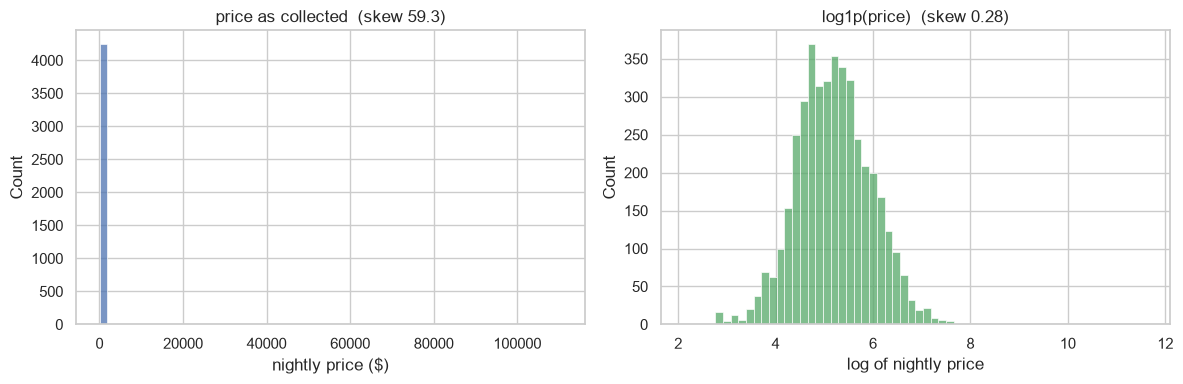

In [3]:
# Log the price. log1p rather than log so a $0 quote wouldn't blow up.
df["price_log"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["price"].dropna(), bins=60, color="#4c72b0", ax=axes[0])
axes[0].set_title(f"price as collected  (skew {df['price'].skew():.1f})")
axes[0].set_xlabel("nightly price ($)")

sns.histplot(df["price_log"].dropna(), bins=60, color="#55a868", ax=axes[1])
axes[1].set_title(f"log1p(price)  (skew {df['price_log'].skew():.2f})")
axes[1].set_xlabel("log of nightly price")

plt.tight_layout()
plt.show()


In [4]:
priced = df["price"].dropna()
print(f"Listings with a price: {priced.size:,}      still blank from Assignment 6: {df['price'].isna().sum():,}")
print(f"Skew before: {priced.skew():.2f}      after log1p: {df['price_log'].skew():.2f}")

print("\nWhere the prices actually sit:")
print(priced.quantile([0.25, 0.50, 0.75, 0.95, 0.99]).round(2).to_string())

print(f"\nListings priced over $2,000 a night: {(priced > 2000).sum()}")
print(df.nlargest(3, "price")[["name", "room_type", "accommodates", "minimum_nights",
                               "price", "price_quote_total_price"]].to_string(index=False))


Listings with a price: 4,251      still blank from Assignment 6: 688
Skew before: 59.30      after log1p: 0.28

Where the prices actually sit:
0.25     106.00
0.50     176.45
0.75     291.00
0.95     645.26
0.99    1159.50

Listings priced over $2,000 a night: 9
                                            name       room_type  accommodates  minimum_nights    price  price_quote_total_price
                                          Marion Entire home/apt             2            30.0 110616.6                3318498.0
Newly Redecorated! Central Park Family Favorite! Entire home/apt             5             1.0  23573.0                  23573.0
                     The Ramble Hotel, Bunkhouse    Private room             2            29.0   9690.0                 281010.0


### Reflection:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?

### ✍️ Your Response: 🔧

1. `price`, the nightly rate in the Denver file. 4,251 listings have one, 688 are still blank, and that's where Assignment 6 left them.

2. A log, using `np.log1p`. Skew of 59.3 on the raw column, and the histogram shows what that actually looks like: everything stacks into one bar at the left edge and the rest of the axis is dead space, because a single listing at $110,616 sets the width of the whole chart. I used `log1p` over plain `log` so a $0 quote wouldn't blow up, though the cheapest listing here is $7.38 anyway. Skew afterward is 0.28.

3. You can read the second chart. The bulk sits between about $100 and $300 with a right tail that tapers instead of stopping at a wall. That $110,616 listing is still in there though. It's the Marion, a two-guest entire home quoting $3.3 million for a 30 night stay, and the log just squeezed it out to the right edge where it stops running the axis. Only 9 listings are over $2,000 a night, so the tail is small and expensive. Good enough to chart and good enough to model. It didn't clean anything, it just made the mess easier to look at.


## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

In [5]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

print(f"number_of_reviews runs {df['number_of_reviews'].min():,.0f} to {df['number_of_reviews'].max():,.0f}")
print(f"price runs ${df['price'].min():,.2f} to ${df['price'].max():,.2f}")

# Min-Max scale: number_of_reviews shrunk to 0-1
df["reviews_minmax"] = MinMaxScaler().fit_transform(df[["number_of_reviews"]])

# Z-score scale: price centered on 0 with a standard deviation of 1.
# StandardScaler rejects nulls, so the 688 unpriced listings are scaled around.
priced_rows = df["price"].notna()
df["price_zscore"] = np.nan
df.loc[priced_rows, "price_zscore"] = StandardScaler().fit_transform(df.loc[priced_rows, ["price"]])

df[["number_of_reviews", "reviews_minmax", "price", "price_zscore"]].head()


number_of_reviews runs 0 to 1,798
price runs $7.38 to $110,616.60


,number_of_reviews,reviews_minmax,price,price_zscore
0,186,0.103448,106.35,-0.096805
1,87,0.048387,32.35,-0.139020
2,221,0.122914,80.00,-0.111837
3,252,0.140156,44.27,-0.132220
4,278,0.154616,191.72,-0.048104


In [6]:
print(df[["reviews_minmax", "price_zscore"]].describe().round(3).to_string())

print(f"\nListings with reviews_minmax under 0.05: {(df['reviews_minmax'] < 0.05).mean():.1%}")
print(f"Largest price z-score: {df['price_zscore'].max():.1f}")
print(f"99th percentile price z-score: {df['price_zscore'].quantile(0.99):.2f}")


       reviews_minmax  price_zscore
count        4939.000      4251.000
mean            0.040        -0.000
std             0.070         1.000
min             0.000        -0.153
25%             0.002        -0.097
50%             0.012        -0.057
75%             0.047         0.009
max             1.000        62.946

Listings with reviews_minmax under 0.05: 76.0%
Largest price z-score: 62.9
99th percentile price z-score: 0.50


In [7]:
# Same scaler on the logged price from part 2, to see if the skew was the problem.
logged_rows = df["price_log"].notna()
df["price_log_zscore"] = np.nan
df.loc[logged_rows, "price_log_zscore"] = StandardScaler().fit_transform(df.loc[logged_rows, ["price_log"]])

n_priced = int(df["price"].notna().sum())
print(f"{'column':18s} {'max z':>8s} {'within 1 sd':>13s}")
for col in ["price_zscore", "price_log_zscore"]:
    within = (df[col].abs() < 1).sum() / n_priced
    print(f"{col:18s} {df[col].max():8.2f} {within:12.1%}")
print("\nA normal distribution puts about 68% of values within one standard deviation.")


column                max z   within 1 sd
price_zscore          62.95        99.8%
price_log_zscore       8.25        69.6%

A normal distribution puts about 68% of values within one standard deviation.



### Reflection:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

### ✍️ Your Response: 🔧

1. Min-Max on `number_of_reviews`, which runs 0 to 1,798, and Z-score on `price`, which runs $7.38 to $110,616.60. Both went in as new columns, `reviews_minmax` and `price_zscore`.

2. Whenever the two have to sit in the same calculation. Anything distance based, like the clustering in Assignment 9, would let price run the result over reviews just because the numbers are bigger. Same for a regression with a penalty term. Scaled columns also make the coefficients comparable to each other instead of an artifact of whatever units they came in.

3. Whoever builds the model, so the data science team. What I actually got out of this section was what scaling doesn't do. Min-Max put 76% of listings under 0.05, because one property has 1,798 reviews and sets the top of the range on its own. The price z-score is worse. It maxes out at 62.9, and 99.8% of priced listings land inside one standard deviation, which sounds tidy until you notice what it means: a handful of listings are setting the scale and everything real got crushed into the middle. Run the same scaler on the logged price and you get a max of 8.25 with 69.6% inside one standard deviation, right about the 68% a normal distribution should give. So the fix for `price` was part 2, not the scaler.


## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

In [8]:
# Cut points set on what they mean to marketing rather than on equal thirds.
# Under 10 reviews is a listing that still has to prove itself, 50 or more books.
bins = [-1, 9, 49, np.inf]
labels = ["Low", "Medium", "High"]

df["review_activity"] = pd.cut(df["number_of_reviews"], bins=bins, labels=labels)

print("Listings per band:")
print(df["review_activity"].value_counts().reindex(labels).to_string())

df[["number_of_reviews", "review_activity"]].head()


Listings per band:
review_activity
Low       1884
Medium    1289
High      1766


,number_of_reviews,review_activity
0,186,High
1,87,High
2,221,High
3,252,High
4,278,High


In [9]:
# Do the three bands behave differently, or is the split only cosmetic?
profile = df.groupby("review_activity", observed=True).agg(
    listings=("id", "size"),
    median_price=("price", "median"),
    median_revenue=("estimated_revenue_l365d", "median"),
    median_nights_booked=("estimated_occupancy_l365d", "median"),
)
print(profile.round(2).to_string())


                 listings  median_price  median_revenue  median_nights_booked
review_activity                                                              
Low                  1884        123.02          1082.5                   0.0
Medium               1289        210.14         20268.5                  98.0
High                 1766        214.54         38248.0                 189.0


### Reflection:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?

### ✍️ Your Response: 🔧

1. `number_of_reviews`, into three bands. Low is under 10 reviews (1,884 listings), Medium is 10 to 49 (1,289), High is 50 or more (1,766). I set the cut points on what they mean to the business instead of using `qcut`, since equal thirds wouldn't tell a marketer anything about which listings are worth contacting.

2. Because nobody can act on "72 reviews." They can act on "High." A campaign needs three lists, not a sorted spreadsheet. Named bands also give the team something to argue about, and if somebody thinks Low should stop at 5 instead of 10, that's an argument about the business rule rather than about the code.

3. Marketing gets the segments the brief asked for, and they hold up. Median estimated revenue runs $1,082.50 for Low, $20,268.50 for Medium and $38,248 for High, and median nights booked runs 0, 98 and 189. Low is mostly listings that aren't booking at all, which is a completely different problem from a listing that books fine and just needs promoting. Three groups, three campaigns.


## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

In [10]:
# 1. Ratio: what a guest pays per head, so listings of different sizes compare.
df["price_per_person"] = df["price"] / df["accommodates"]

# 2. Flag: Denver treats a stay of 30 nights or more as a long-term rental,
#    which is a different business from a nightly one.
df["long_stay_listing"] = (df["minimum_nights"] >= 30).astype(int)

df[["price", "accommodates", "price_per_person", "minimum_nights", "long_stay_listing"]].head()


,price,accommodates,price_per_person,minimum_nights,long_stay_listing
0,106.35,2,53.175000,29.0,0
1,32.35,3,10.783333,185.0,1
2,80.00,2,40.000000,2.0,0
3,44.27,1,44.270000,30.0,1
4,191.72,2,95.860000,1.0,0


In [11]:
print("Headline price vs price per person, median by room type:")
print(df.groupby("room_type", observed=True)[["price", "price_per_person"]].median().round(2).to_string())


Headline price vs price per person, median by room type:
                  price  price_per_person
room_type                                
Entire home/apt  190.59             52.00
Hotel room       378.00             91.00
Private room     106.00             52.78
Shared room       35.00             22.42


In [12]:
print("Most common minimum_nights values:")
print(df["minimum_nights"].value_counts().head(6).to_string())

compare = df.groupby("long_stay_listing", observed=True).agg(
    listings=("id", "size"),
    median_price=("price", "median"),
    median_reviews=("number_of_reviews", "median"),
    median_revenue=("estimated_revenue_l365d", "median"),
)
print("\n0 = nightly rental, 1 = 30 night minimum or longer")
print(compare.round(2).to_string())

print(f"\nMedian nightly price, all listings:        ${df['price'].median():,.2f}")
print(f"Median nightly price, long stays removed:  ${df.loc[df['long_stay_listing'] == 0, 'price'].median():,.2f}")


Most common minimum_nights values:
minimum_nights
1.0     1337
29.0    1324
30.0     991
2.0      857
3.0      204
4.0       38

0 = nightly rental, 1 = 30 night minimum or longer
                   listings  median_price  median_reviews  median_revenue
long_stay_listing                                                        
0                      3818        209.79            36.0         23092.0
1                      1121        100.63             3.0          1275.0

Median nightly price, all listings:        $176.45
Median nightly price, long stays removed:  $209.79


In [13]:
# Why 30 nights is the line: below it a Denver listing needs a short-term rental license.
license_state = pd.Series(
    np.where(df["license"].astype(str).str.strip().str.lower() == "not listed",
             "no license on file", "license on file"),
    index=df.index, name="license",
)
nights_band = pd.cut(df["minimum_nights"], [0, 28, 29, 30, np.inf],
                     labels=["1 to 28", "exactly 29", "exactly 30", "31 or more"])

print("Percent of listings in each band, by license:")
print(pd.crosstab(nights_band, license_state, normalize="index").mul(100).round(1).to_string())


Percent of listings in each band, by license:
license         license on file  no license on file
minimum_nights                                     
1 to 28                    98.9                 1.1
exactly 29                 43.5                56.5
exactly 30                 10.7                89.3
31 or more                 13.8                86.2


### Reflection:
1. What two new columns did you create and why?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

### ✍️ Your Response: 🔧

1. `price_per_person`, which is `price` over `accommodates`, and `long_stay_listing`, a flag for `minimum_nights >= 30`. The ratio came from headline price not being comparable across listings of different sizes. Median price is $190.59 for an entire home against $106.00 for a private room, so the room looks like the bargain. Per guest they're $52.00 and $52.78. Basically the same. The flag came out of the `minimum_nights` counts, which don't look natural: 1,337 listings at 1 night, then 1,324 at exactly 29 and 991 at exactly 30.

2. Price per person is for a guest picking between options, and for a pricing analyst comparing listings that sleep different numbers of people. The flag is for anybody reporting Denver averages, and for the city, since 30 nights is where a short-term rental license stops being required.

3. The long-stay group is 1,121 listings with a median price of $100.63 against $209.79 for everyone else, 3 reviews against 36, and $1,275 of estimated annual revenue against $23,092. They're barely running as nightly rentals. Leave them in the pool and the citywide median nightly price drops from $209.79 to $176.45, so anybody quoting that number is averaging two different businesses together. The licensing side is what I didn't see coming. 98.9% of listings with a minimum of 28 nights or fewer have a license on file, and at exactly 30 nights only 10.7% do. That's a regulation showing up in the data, not a bunch of hosts who happen to like month-long stays.


## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

In [14]:
print("room_type values:")
print(df["room_type"].value_counts().to_string())

print("\nShape before encoding:", df.shape)

# Nominal, so one-hot. A hotel room doesn't outrank a private room, and an
# integer code would hand the model an order that isn't there.
df = pd.get_dummies(df, columns=["room_type"], prefix="room_type")

room_cols = [c for c in df.columns if c.startswith("room_type_")]
print("Shape after encoding: ", df.shape)
print("Columns added:", room_cols)

df[room_cols].head()


room_type values:
room_type
Entire home/apt    4233
Private room        631
Shared room          52
Hotel room           23

Shape before encoding: (4939, 80)
Shape after encoding:  (4939, 83)
Columns added: ['room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']


,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,True,False,False,False
1,True,False,False,False
2,False,False,True,False
3,False,False,True,False
4,True,False,False,False


In [15]:
# Check the dummies flag real rows instead of coming back False everywhere.
print("Listings flagged in each new column:")
print(df[room_cols].sum().to_string())

# review_activity from part 4 is genuinely ordered, so one integer column carries it.
df["review_activity_ordinal"] = df["review_activity"].map({"Low": 0, "Medium": 1, "High": 2}).astype("Int64")

print("\nOrdinal encoding of review_activity:")
print(df.groupby("review_activity", observed=True)["review_activity_ordinal"].first().to_string())


Listings flagged in each new column:
room_type_Entire home/apt    4233
room_type_Hotel room           23
room_type_Private room        631
room_type_Shared room          52

Ordinal encoding of review_activity:
review_activity
Low       0
Medium    1
High      2


### Reflection:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?

### ✍️ Your Response: 🔧

1. `room_type`. Four values, and it's the clearest thing in the file about what a guest is actually booking, which makes it worth having in a price model.

2. One-hot, through `pd.get_dummies`, so four boolean columns. It's nominal. A hotel room doesn't outrank a private room, so an integer code would hand the model an order that isn't there. I did go ordinal on `review_activity` from part 4, since Low, Medium and High really are ranked and one integer column carries that without spending three on it. The method should follow the column.

3. No model reads the words "Shared room," so this is the step that gets `room_type` into a regression at all, and once it's in, each type gets its own effect on price instead of being averaged away. The dummies are also what a dashboard filter sits on. One thing to watch: the column is badly lopsided. 4,233 of 4,939 listings are entire homes and 23 are hotel rooms, so `room_type_Hotel room` has 23 rows behind it. I wouldn't read much into whatever coefficient it ends up with.


## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [16]:
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - In Colab the file lands in the Files tab, where the three-dot menu will download it

drop_cols = [
    # links and images: nothing to model, and they make the file heavier
    "listing_url", "picture_url", "host_url", "host_picture_url",
    "host_profile_url", "host_profile_id",
    # scrape bookkeeping
    "last_scraped", "calendar_last_scraped",
    # the raw quote JSON and its parts. price already holds the per-night figure
    "price_quote_raw", "price_quote_checkin_date", "price_quote_checkout_date",
    "price_quote_total_price", "price_quote_price_per_night",
    # near duplicate nights columns carried over from the source file
    "minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights",
    "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    # long free text, no use until a text analytics assignment
    "description", "amenities",
]

df_out = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Types that were still sitting as text
for col in ["first_review", "last_review"]:
    df_out[col] = pd.to_datetime(df_out[col], errors="coerce")

for col in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]:
    df_out[col] = df_out[col].map({"t": 1, "f": 0}).astype("Int64")

df_out.to_csv("cleaned_airbnb_data_7.csv", index=False)

print("Saved cleaned_airbnb_data_7.csv")
print("Columns in: ", df.shape[1], " out:", df_out.shape[1], " rows:", len(df_out))


Saved cleaned_airbnb_data_7.csv
Columns in:  84  out: 63  rows: 4939


In [17]:
built_here = ["price_log", "reviews_minmax", "price_zscore", "price_log_zscore",
              "review_activity", "review_activity_ordinal", "price_per_person",
              "long_stay_listing"] + room_cols

print("Columns built in this assignment:")
print(df_out[built_here].dtypes.to_string())

print("\nNulls in those columns:")
print(df_out[built_here].isna().sum().to_string())

df_out[["price", "price_log", "price_per_person", "review_activity",
        "long_stay_listing", "room_type_Entire home/apt"]].head()


Columns built in this assignment:
price_log                     float64
reviews_minmax                float64
price_zscore                  float64
price_log_zscore              float64
review_activity              category
review_activity_ordinal         Int64
price_per_person              float64
long_stay_listing               int64
room_type_Entire home/apt        bool
room_type_Hotel room             bool
room_type_Private room           bool
room_type_Shared room            bool

Nulls in those columns:
price_log                    688
reviews_minmax                 0
price_zscore                 688
price_log_zscore             688
review_activity                0
review_activity_ordinal        0
price_per_person             688
long_stay_listing              0
room_type_Entire home/apt      0
room_type_Hotel room           0
room_type_Private room         0
room_type_Shared room          0


,price,price_log,price_per_person,review_activity,long_stay_listing,room_type_Entire home/apt
0,106.35,4.676095,53.175000,High,0,True
1,32.35,3.507058,10.783333,High,1,True
2,80.00,4.394449,40.000000,High,0,False
3,44.27,3.812645,44.270000,High,1,False
4,191.72,5.261238,95.860000,High,0,True


## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### Reflection:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. Part 5, building the two new columns. Scaling and binning are mechanical once you know which function to call. Deciding that price per person is the honest comparison, and that a 30 night minimum means something specific in Denver, meant actually looking at the file instead of just running a transform over it. The `minimum_nights` counts gave it away. Nobody's preferences pile 1,324 listings on exactly 29 and another 991 on exactly 30.

2. `long_stay_listing` for a city planner, `price_per_person` for a host. The flag splits two businesses the raw file blends together, and it lines up almost exactly with whether a license is on record, so the city can see the shape of what it's regulating instead of one averaged number. A host gets more out of price per person, since it answers whether they're priced sensibly against a listing that sleeps a different number of people. The headline number never answers that.

3. Split the dashboard on `long_stay_listing` first, so nightly and monthly rentals never share an average, then put `review_activity` next to it as the filter. After that I'd go back to `price`. The transform in part 2 makes that $110,616 row survivable, but survivable isn't fixed, and 9 listings over $2,000 a night is a short enough list to check by hand. I'd rather do that with whoever owns the pricing question than quietly drop rows on my own.

4. Both of my outcomes are about marketing analytics, and this assignment lands on both. The first is using Python to prep customer and campaign data well enough to build segments and tell whether an effort worked. Part 4 is that, straight through: three review-activity bands that separate on revenue and on nights booked, so a campaign can be measured against them instead of just labeled. Part 5 comes at it from the other side, since pulling monthly rentals out of the nightly pool decides whether the baseline you're measuring against is honest in the first place. The second outcome is about turning that into recommendations while handling privacy, bias and the ethical limits of consumer data, and the license finding is where that bites. I can pull something that looks like a compliance signal out of a scraped file, but "not listed" means the scraper didn't catch a license, not that the host doesn't have one. Publishing it as a compliance rate would be an accusation the data can't back. As an observation about how the market is shaped it's fine. As a list of names it isn't, which is why I dropped `host_name` in Assignment 6.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [18]:
!jupyter nbconvert --to html "assignment_07_data_transformation.ipynb"

[NbConvertApp] Converting notebook assignment_07_data_transformation.ipynb to html


[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).


[NbConvertApp] Writing 431423 bytes to assignment_07_data_transformation.html
